<a href="https://colab.research.google.com/github/klairebuilds-nano/BioSignals-Labwork/blob/main/Lab_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install wfdb
import wfdb
import numpy as np
import matplotlib.pyplot as plt

record = wfdb.rdrecord('100', pn_dir='mitdb', sampto=3600)
fs = record.fs
ecg = record.p_signal[:, 0]
t = np.arange(len(ecg)) / fs

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 37.4 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.3 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.3 which is incompatible.


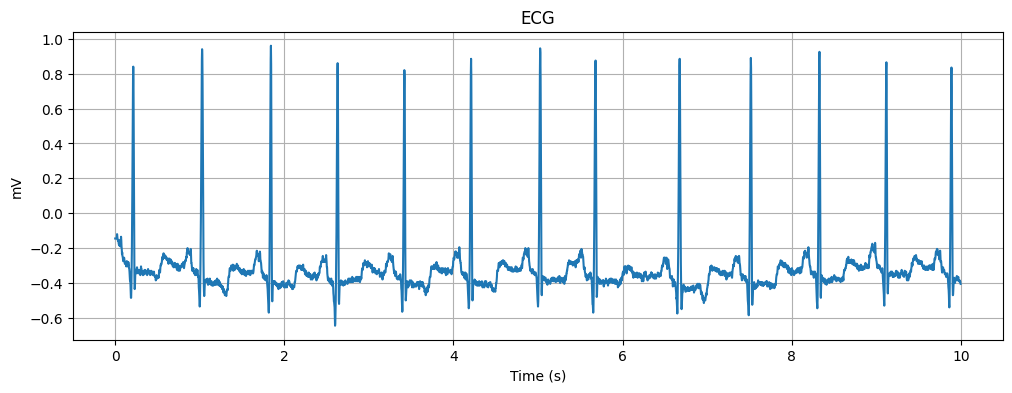

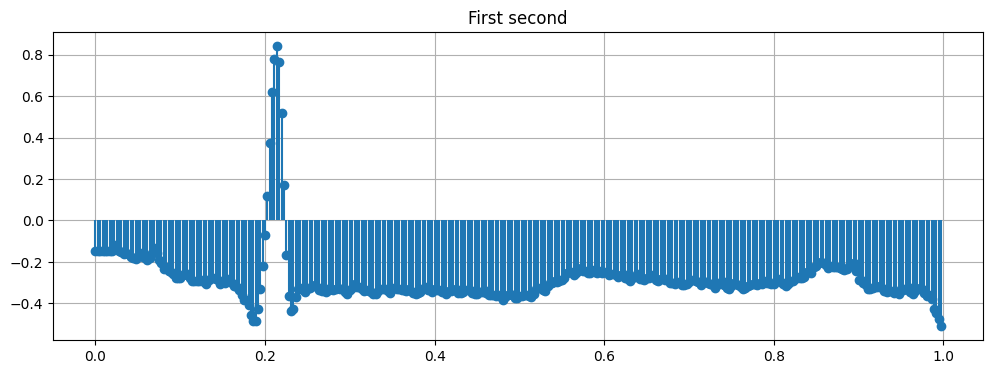

In [2]:
plt.figure(figsize=(12, 4))
plt.plot(t, ecg)
plt.title('ECG'); plt.xlabel('Time (s)'); plt.ylabel('mV')
plt.grid(True); plt.show()

# Zoom to 1 second to see individual samples
plt.figure(figsize=(12, 4))
plt.stem(t[:int(fs)], ecg[:int(fs)], basefmt=' ')
plt.title('First second'); plt.grid(True); plt.show()

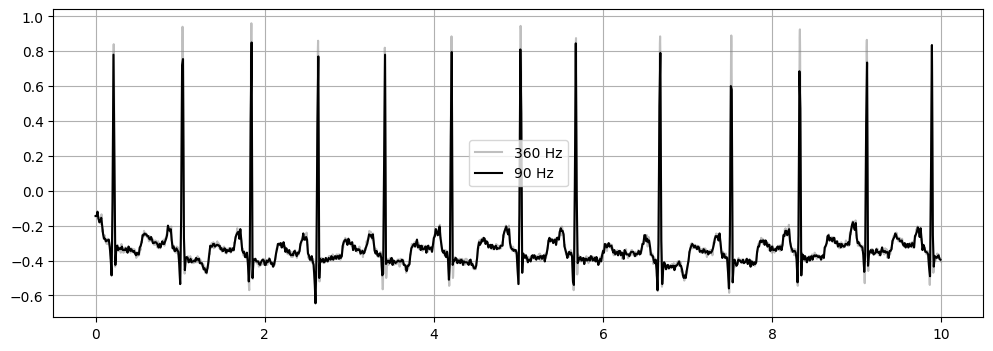

In [3]:
factor = 4
ecg_ds = ecg[::factor]
fs_ds = fs / factor
t_ds = np.arange(len(ecg_ds)) / fs_ds

plt.figure(figsize=(12, 4))
plt.plot(t, ecg, 'gray', alpha=0.5, label='360 Hz')
plt.plot(t_ds, ecg_ds, 'k', label=f'{fs_ds:.0f} Hz')
plt.legend(); plt.grid(True); plt.show()

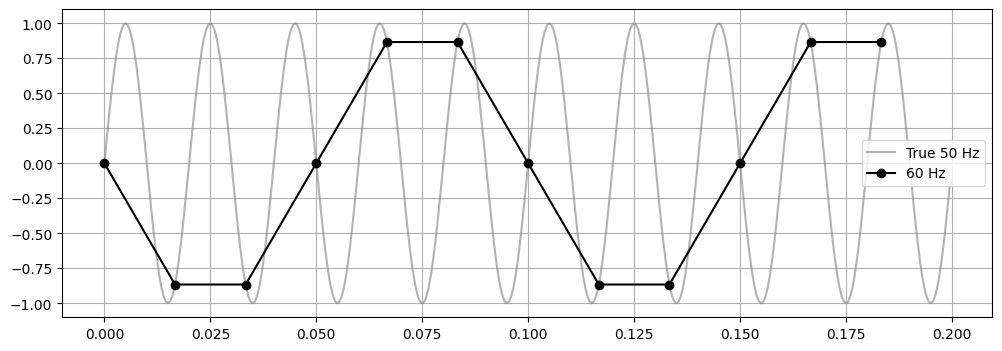

Apparent frequency: 10 Hz


In [4]:
f_tone = 50
tt = np.arange(0, 0.2, 1/2000)
tone = np.sin(2*np.pi*f_tone*tt)
fs_bad = 60 # < 2 x 50 -> aliasing
nb = np.arange(0, 0.2, 1/fs_bad)
tone_bad = np.sin(2*np.pi*f_tone*nb)

plt.figure(figsize=(12, 4))
plt.plot(tt, tone, 'gray', alpha=0.6, label='True 50 Hz')
plt.plot(nb, tone_bad, 'ko-', label=f'{fs_bad} Hz')
plt.legend(); plt.grid(True); plt.show()

alias = abs(f_tone - round(f_tone/fs_bad)*fs_bad)
print('Apparent frequency:', alias, 'Hz')

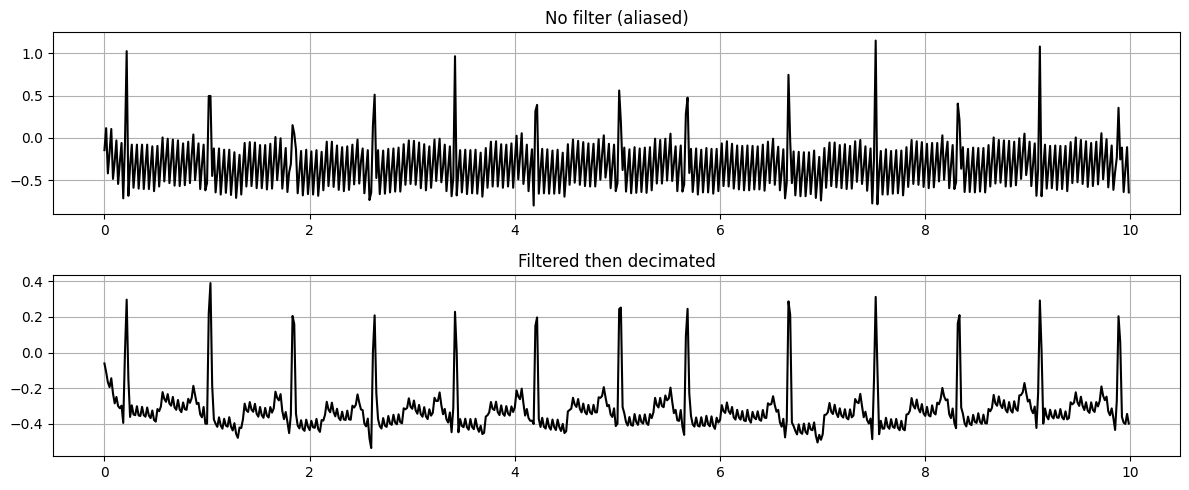

In [5]:
ecg_noisy = ecg + 0.3*np.sin(2*np.pi*80*t) # add 80 Hz interference
naive = ecg_noisy[::6] # no filter
ecg_lp = np.convolve(ecg_noisy, np.ones(12)/12, mode='same')
decimated = ecg_lp[::6] # filter then downsample
t_new = np.arange(len(naive)) / (fs/6)

plt.figure(figsize=(12, 5))
plt.subplot(2,1,1); plt.plot(t_new, naive, 'k')
plt.title('No filter (aliased)'); plt.grid(True)
plt.subplot(2,1,2); plt.plot(t_new, decimated, 'k')
plt.title('Filtered then decimated'); plt.grid(True)
plt.tight_layout(); plt.show()

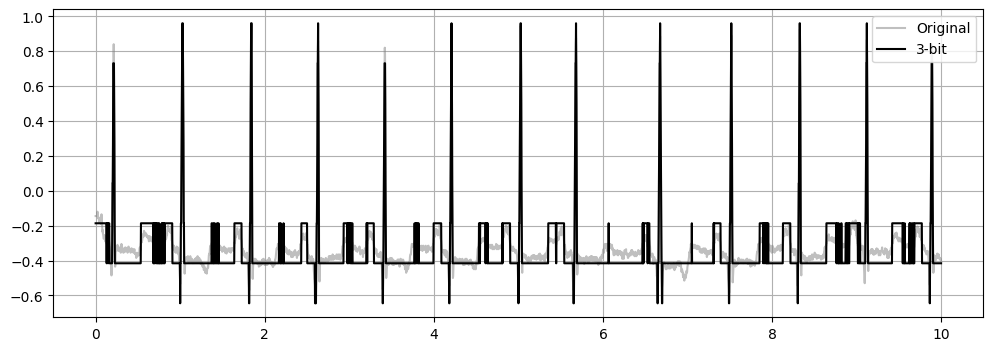

3-bit -> SQNR = 14.4 dB


In [6]:
def quantize(sig, bits):
    levels = 2 ** bits
    smin, smax = sig.min(), sig.max()
    step = (smax - smin) / (levels - 1)
    return np.round((sig - smin)/step)*step + smin

bits = 3
ecg_q = quantize(ecg, bits)

plt.figure(figsize=(12, 4))
plt.plot(t, ecg, 'gray', alpha=0.5, label='Original')
plt.plot(t, ecg_q, 'k', label=f'{bits}-bit')
plt.legend(); plt.grid(True); plt.show()

sqnr = 10*np.log10(np.sum(ecg**2) / np.sum((ecg-ecg_q)**2))
print(f'{bits}-bit -> SQNR = {sqnr:.1f} dB')

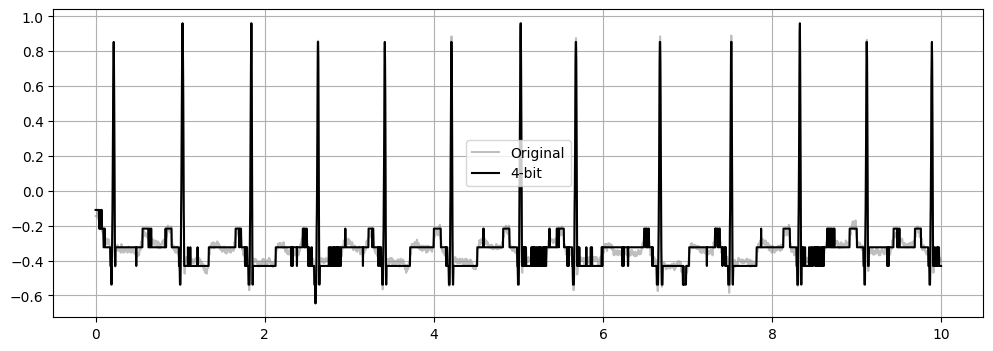

4-bit -> SQNR = 21.5 dB


In [7]:
def quantize(sig, bits):
    levels = 2 ** bits
    smin, smax = sig.min(), sig.max()
    step = (smax - smin) / (levels - 1)
    return np.round((sig - smin)/step)*step + smin

bits = 4
ecg_q = quantize(ecg, bits)

plt.figure(figsize=(12, 4))
plt.plot(t, ecg, 'gray', alpha=0.5, label='Original')
plt.plot(t, ecg_q, 'k', label=f'{bits}-bit')
plt.legend(); plt.grid(True); plt.show()

sqnr = 10*np.log10(np.sum(ecg**2) / np.sum((ecg-ecg_q)**2))
print(f'{bits}-bit -> SQNR = {sqnr:.1f} dB')

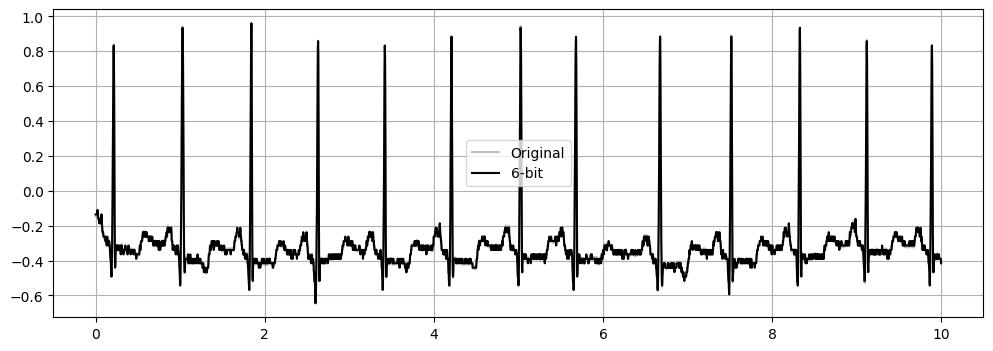

6-bit -> SQNR = 33.9 dB


In [8]:
def quantize(sig, bits):
    levels = 2 ** bits
    smin, smax = sig.min(), sig.max()
    step = (smax - smin) / (levels - 1)
    return np.round((sig - smin)/step)*step + smin

bits = 6
ecg_q = quantize(ecg, bits)

plt.figure(figsize=(12, 4))
plt.plot(t, ecg, 'gray', alpha=0.5, label='Original')
plt.plot(t, ecg_q, 'k', label=f'{bits}-bit')
plt.legend(); plt.grid(True); plt.show()

sqnr = 10*np.log10(np.sum(ecg**2) / np.sum((ecg-ecg_q)**2))
print(f'{bits}-bit -> SQNR = {sqnr:.1f} dB')

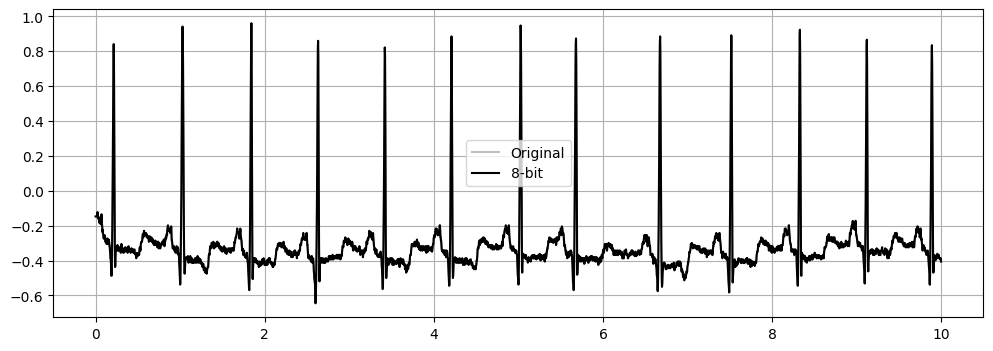

8-bit -> SQNR = 46.1 dB


In [9]:
def quantize(sig, bits):
    levels = 2 ** bits
    smin, smax = sig.min(), sig.max()
    step = (smax - smin) / (levels - 1)
    return np.round((sig - smin)/step)*step + smin

bits = 8
ecg_q = quantize(ecg, bits)

plt.figure(figsize=(12, 4))
plt.plot(t, ecg, 'gray', alpha=0.5, label='Original')
plt.plot(t, ecg_q, 'k', label=f'{bits}-bit')
plt.legend(); plt.grid(True); plt.show()

sqnr = 10*np.log10(np.sum(ecg**2) / np.sum((ecg-ecg_q)**2))
print(f'{bits}-bit -> SQNR = {sqnr:.1f} dB')

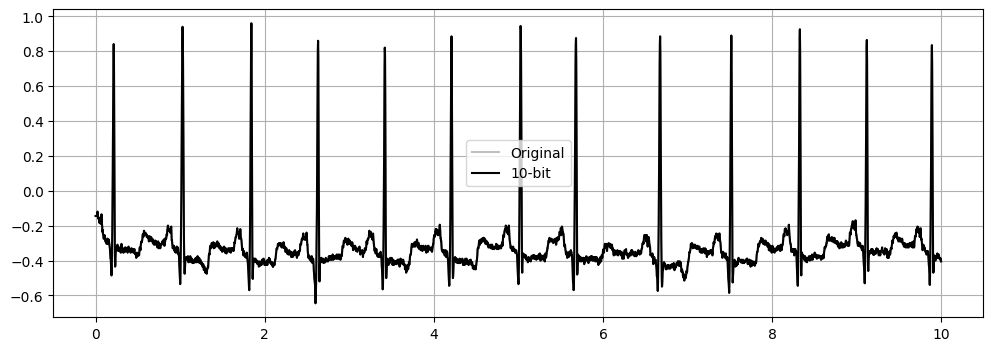

10-bit -> SQNR = 58.0 dB


In [10]:
def quantize(sig, bits):
    levels = 2 ** bits
    smin, smax = sig.min(), sig.max()
    step = (smax - smin) / (levels - 1)
    return np.round((sig - smin)/step)*step + smin

bits = 10
ecg_q = quantize(ecg, bits)

plt.figure(figsize=(12, 4))
plt.plot(t, ecg, 'gray', alpha=0.5, label='Original')
plt.plot(t, ecg_q, 'k', label=f'{bits}-bit')
plt.legend(); plt.grid(True); plt.show()

sqnr = 10*np.log10(np.sum(ecg**2) / np.sum((ecg-ecg_q)**2))
print(f'{bits}-bit -> SQNR = {sqnr:.1f} dB')